# Laptop Price Prediction — Reproducible Model Evaluation

This notebook reproduces the final evaluation used in the IEEE-style paper and presentation.

**Important interpretation**

- The target is an INR-denominated historical price.
- R² is explained variation, **not percentage accuracy**.
- MAE and RMSE are reported in INR after reversing the log transform.
- USD output is currency conversion, not a US-market model.
- The 15% test set remains untouched during model selection and interval calibration.


In [1]:
from pathlib import Path
import sys, json, warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (r2_score, mean_absolute_error,
                             mean_squared_error, median_absolute_error)
from sklearn.model_selection import train_test_split

# If the notebook is inside <project>/notebooks, this resolves automatically.
# Otherwise, set PROJECT manually to the research-project directory.
candidate = Path.cwd()
if not (candidate / "src").exists() and (candidate.parent / "src").exists():
    candidate = candidate.parent
PROJECT = candidate.resolve()
print("Project:", PROJECT)
sys.path.insert(0, str(PROJECT))
from src.features import engineer_features

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")


Project: /Users/waiyan/Documents/2nd semester/Unity/ai/implementation/laptop-price-prediction-research


## 1. Load the dataset and trained research artifacts

The notebook intentionally loads the serialized pipeline selected during five-fold cross-validation. It reconstructs the deterministic test partition using the saved random seed.


In [2]:
DATA = PROJECT / "data/laptop_data.csv"
MODEL = PROJECT / "artifacts/model.joblib"
METADATA = PROJECT / "artifacts/metadata.json"
COMPARISON = PROJECT / "reports/model_comparison.csv"

raw = pd.read_csv(DATA)
model = joblib.load(MODEL)
metadata = json.loads(METADATA.read_text())
comparison = pd.read_csv(COMPARISON).sort_values("cv_rmse_log_mean")

print("Rows:", len(raw))
print("Selected model:", metadata["selected_model"])
print("Split:", metadata["split"])
raw.head()


Rows: 1303
Selected model: RandomForest
Split: {'train': 912, 'calibration': 195, 'test': 196}


,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3000,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,"71,378.6832"
1,1,Apple,Ultrabook,13.3000,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,"47,895.5232"
2,2,HP,Notebook,15.6000,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,"30,636.0000"
3,3,Apple,Ultrabook,15.4000,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,"135,195.3360"
4,4,Apple,Ultrabook,13.3000,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,"96,095.8080"


## 2. Reconstruct the 70/15/15 partition

The model was fitted on 70% of the data. The calibration set supplied residuals for the 90% interval. The final 15% test set is used only here.


In [3]:
X = engineer_features(raw)
y_log = np.log(pd.to_numeric(raw[metadata["target"]], errors="raise").to_numpy())

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_log, test_size=0.30, random_state=metadata["random_state"]
)
X_cal, X_test, y_cal, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=metadata["random_state"]
)

assert [len(X_train), len(X_cal), len(X_test)] == [912, 195, 196]
print(f"Train={len(X_train)}, calibration={len(X_cal)}, test={len(X_test)}")


Train=912, calibration=195, test=196


## 3. Predict the untouched test partition

The model predicts natural-log price. `np.exp` returns predictions to the INR scale.


In [4]:
pred_log = model.predict(X_test)
actual_inr = np.exp(y_test)
predicted_inr = np.exp(pred_log)

interval_q = metadata["test_metrics"]["interval_log_half_width"]
lower_90 = np.exp(pred_log - interval_q)
upper_90 = np.exp(pred_log + interval_q)

predictions = pd.DataFrame({
    "actual_inr": actual_inr,
    "predicted_inr": predicted_inr,
    "residual_inr": actual_inr - predicted_inr,
    "absolute_error_inr": np.abs(actual_inr - predicted_inr),
    "lower_90_inr": lower_90,
    "upper_90_inr": upper_90,
    "covered_90": (actual_inr >= lower_90) & (actual_inr <= upper_90),
})
predictions.head()


,actual_inr,predicted_inr,residual_inr,absolute_error_inr,lower_90_inr,upper_90_inr,covered_90
0,"18,594.7200","17,154.9606","1,439.7594","1,439.7594","11,969.2614","24,587.3710",True
1,"39,373.9200","44,042.1423","-4,668.2223","4,668.2223","30,728.8328","63,123.4616",True
2,"51,095.5200","55,049.6684","-3,954.1484","3,954.1484","38,408.9413","78,900.0137",True
3,"94,252.3200","105,937.1880","-11,684.8680","11,684.8680","73,913.8918","151,834.6219",True
4,"14,332.3200","16,505.6055","-2,173.2855","2,173.2855","11,516.1971","23,656.6821",True


## 4. Calculate evaluation metrics

- **R²:** explained variation on log price.
- **MAE:** typical absolute currency error.
- **RMSE:** penalizes large errors more strongly.
- **Median AE:** robust typical error.
- **MAPE:** average relative error; interpret carefully near zero targets.
- **Coverage:** fraction of true prices inside the nominal 90% interval.


In [5]:
metrics = pd.Series({
    "R2_log_price": r2_score(y_test, pred_log),
    "MAE_INR": mean_absolute_error(actual_inr, predicted_inr),
    "RMSE_INR": mean_squared_error(actual_inr, predicted_inr) ** 0.5,
    "Median_AE_INR": median_absolute_error(actual_inr, predicted_inr),
    "MAPE_percent": np.mean(np.abs((actual_inr - predicted_inr) / actual_inr)) * 100,
    "Nominal_coverage": 0.90,
    "Empirical_coverage": predictions["covered_90"].mean(),
})
metrics.to_frame("value")


,value
R2_log_price,0.8738
MAE_INR,"9,731.7057"
RMSE_INR,"15,713.8237"
Median_AE_INR,"5,404.8254"
MAPE_percent,17.0993
Nominal_coverage,0.9000
Empirical_coverage,0.9184


In [6]:
# Verify agreement with the saved paper results.
saved = metadata["test_metrics"]
checks = {
    "R2": np.isclose(metrics["R2_log_price"], saved["r2"]),
    "MAE": np.isclose(metrics["MAE_INR"], saved["mae_inr"]),
    "RMSE": np.isclose(metrics["RMSE_INR"], saved["rmse_inr"]),
    "Coverage": np.isclose(metrics["Empirical_coverage"], saved["interval_empirical_coverage"]),
}
assert all(checks.values()), checks
checks


{'R2': np.True_, 'MAE': np.True_, 'RMSE': np.True_, 'Coverage': np.True_}

## 5. Compare candidate models

All candidates were evaluated using the same five shuffled folds on the training partition. The selection criterion was the lowest mean cross-validated log-RMSE.


,model,cv_r2_mean,cv_r2_std,cv_rmse_log_mean
0,RandomForest,0.8741,0.0128,0.2217
1,GradientBoosting,0.8724,0.0127,0.2232
2,ExtraTrees,0.8575,0.0201,0.2354
3,Ridge,0.8334,0.0166,0.2549


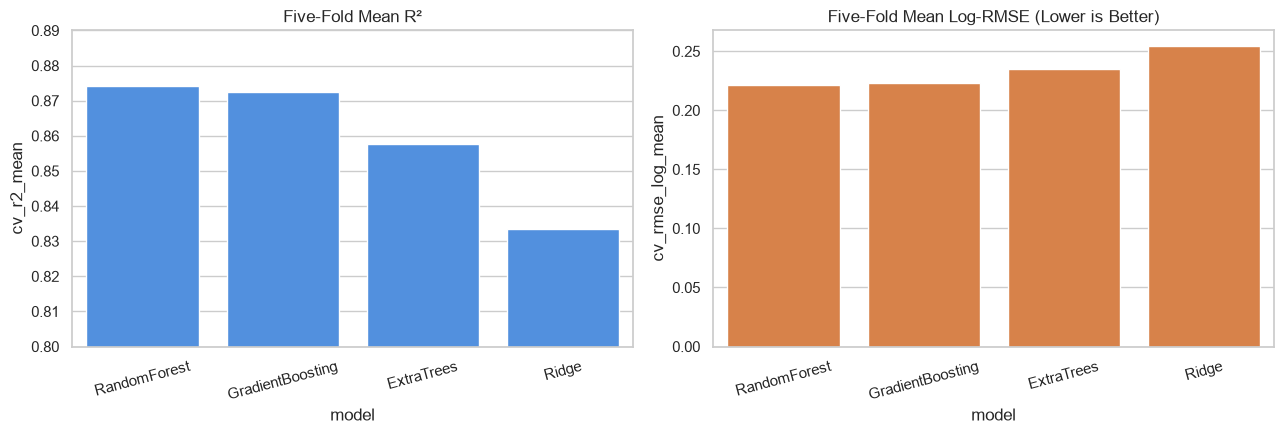

In [7]:
display(comparison[["model", "cv_r2_mean", "cv_r2_std", "cv_rmse_log_mean"]])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(data=comparison, x="model", y="cv_r2_mean", ax=axes[0], color="#3b8df5")
axes[0].set_ylim(0.80, 0.89); axes[0].set_title("Five-Fold Mean R²")
axes[0].tick_params(axis="x", rotation=15)
sns.barplot(data=comparison, x="model", y="cv_rmse_log_mean", ax=axes[1], color="#ef7d32")
axes[1].set_title("Five-Fold Mean Log-RMSE (Lower is Better)")
axes[1].tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.show()


## 6. Prediction and residual diagnostics


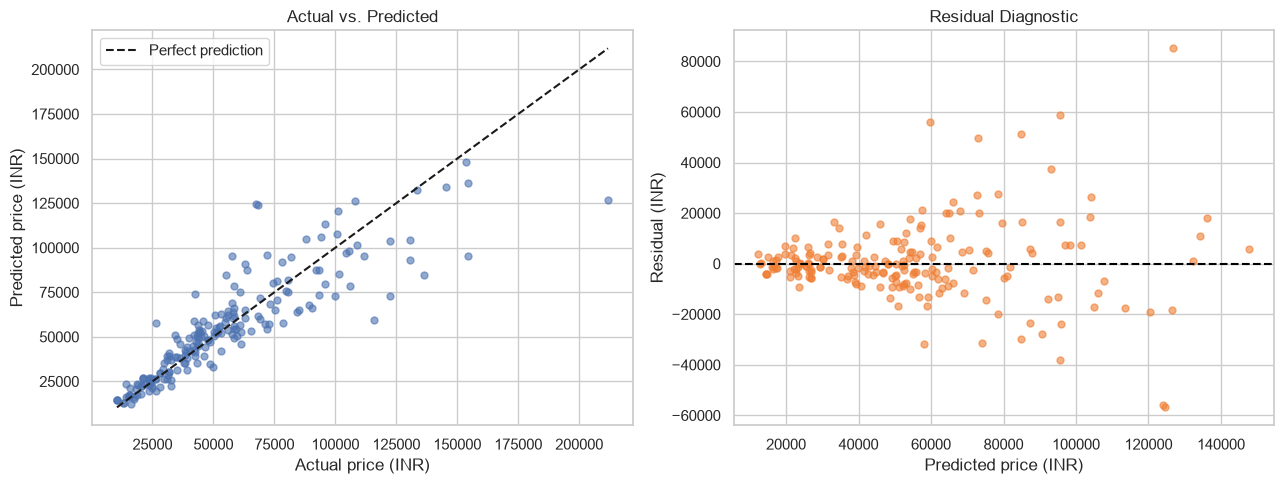

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(actual_inr, predicted_inr, alpha=0.6, s=25)
limits = [min(actual_inr.min(), predicted_inr.min()), max(actual_inr.max(), predicted_inr.max())]
axes[0].plot(limits, limits, "k--", label="Perfect prediction")
axes[0].set(xlabel="Actual price (INR)", ylabel="Predicted price (INR)",
            title="Actual vs. Predicted")
axes[0].legend()

axes[1].scatter(predicted_inr, predictions["residual_inr"], alpha=0.6, s=25, color="#ef7d32")
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set(xlabel="Predicted price (INR)", ylabel="Residual (INR)",
            title="Residual Diagnostic")
plt.tight_layout(); plt.show()


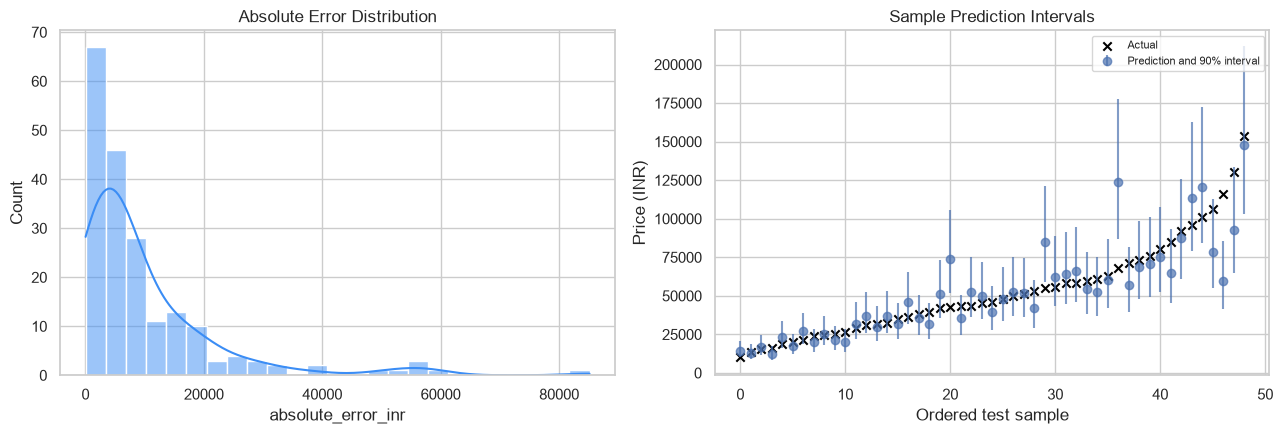

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(predictions["absolute_error_inr"], bins=25, kde=True, ax=axes[0], color="#3b8df5")
axes[0].set_title("Absolute Error Distribution")

ordered = predictions.sort_values("actual_inr").reset_index(drop=True)
sample = ordered.iloc[::max(1, len(ordered)//40)]
axes[1].errorbar(range(len(sample)), sample["predicted_inr"],
                 yerr=[sample["predicted_inr"]-sample["lower_90_inr"],
                       sample["upper_90_inr"]-sample["predicted_inr"]],
                 fmt="o", alpha=0.7, label="Prediction and 90% interval")
axes[1].scatter(range(len(sample)), sample["actual_inr"], marker="x", color="black", label="Actual")
axes[1].set(title="Sample Prediction Intervals", xlabel="Ordered test sample", ylabel="Price (INR)")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


## 7. Error analysis by price band

Segment-level metrics can reveal weaknesses hidden by one overall score. Small groups should be interpreted cautiously.


In [10]:
predictions["price_band"] = pd.qcut(predictions["actual_inr"], q=4,
                                         labels=["Low", "Lower-middle", "Upper-middle", "High"])
band_analysis = predictions.groupby("price_band", observed=True).apply(
    lambda group: pd.Series({
        "samples": len(group),
        "MAE_INR": group["absolute_error_inr"].mean(),
        "MAPE_percent": (group["absolute_error_inr"] / group["actual_inr"]).mean() * 100,
        "coverage_90": group["covered_90"].mean(),
    }), include_groups=False
)
band_analysis


,samples,MAE_INR,MAPE_percent,coverage_90
price_band,,,,
Low,49.0000,"3,481.5786",17.0626,0.9592
Lower-middle,49.0000,"6,457.0673",16.5050,0.9388
Upper-middle,49.0000,"10,314.6734",17.3748,0.8776
High,49.0000,"18,673.5035",17.4547,0.8980


## 8. Optional USD display conversion

This cell converts the INR estimate using a user-supplied exchange rate. It does **not** evaluate US-market accuracy.


In [11]:
INR_PER_USD = 87.0  # Replace with the disclosed rate used in your demonstration.
predictions["predicted_usd_display"] = predictions["predicted_inr"] / INR_PER_USD
predictions[["predicted_inr", "predicted_usd_display"]].head()


,predicted_inr,predicted_usd_display
0,"17,154.9606",197.1835
1,"44,042.1423",506.2315
2,"55,049.6684",632.7548
3,"105,937.1880","1,217.6688"
4,"16,505.6055",189.7196


## 9. Export reproducible results


In [12]:
export_dir = PROJECT / "reports" / "notebook_evaluation"
export_dir.mkdir(parents=True, exist_ok=True)
predictions.to_csv(export_dir / "test_predictions_detailed.csv", index=False)
comparison.to_csv(export_dir / "model_comparison.csv", index=False)
metrics.to_json(export_dir / "test_metrics.json", indent=2)
band_analysis.to_csv(export_dir / "price_band_analysis.csv")
print("Saved results to", export_dir)


Saved results to /Users/waiyan/Documents/2nd semester/Unity/ai/implementation/laptop-price-prediction-research/reports/notebook_evaluation


## Conclusion

The selected Random Forest explains approximately **87.4% of held-out log-price variation**. On the original INR scale, MAE is approximately **₹9,723**, RMSE is **₹15,691**, and MAPE is **17.09%**. The nominal 90% interval obtains approximately **91.84%** empirical coverage.

These are strong within-dataset results. They are not evidence of current-market accuracy because the baseline dataset lacks dates, retailers, geographic context, discount state, warranty, condition, and modern component generations.
